# Cloud I/O — tile-window iteration + Cloud-Optimized GeoTIFF
Two helpers for processing continental-scale rasters without ever loading the full grid:

* **`cloud_io.tile_windows(dataset, tile_rows, tile_cols, overlap)`** — generator yielding
  `pyramids.dataset.Window` tiles in row-major order. A `Window` is x-first
  (`col_off`, `row_off`, `cols`, `rows`) and is exactly what
  `Dataset.read_array(window=...)` takes, so each tile can be streamed straight through
  any per-tile algorithm.
* **`cloud_io.write_cog(dataset, path, compress="deflate")`** — write a Cloud-Optimized GeoTIFF
  (tiled layout + internal overviews) ready for `s3://` / HTTP range reads.

In [1]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 80
plt.rcParams["savefig.dpi"] = 80


In [2]:
import numpy as np
from pyramids.dataset import Dataset, GeoReference
from digitalrivers.cloud_io import tile_windows, write_cog

# Build a 500×500 'continental' DEM (stand-in for a multi-million-cell raster).
rng = np.random.default_rng(seed=2026)
z = rng.uniform(0, 1000, size=(500, 500)).astype(np.float32)
ds = Dataset.from_array(
    z,
    geo_ref=GeoReference(top_left_corner=(0.0, 0.0), cell_size=30.0, epsg=32618),
    no_data_value=-9999.0,
)
print(f"Dataset: {ds.rows}×{ds.columns} cells = {ds.rows * ds.columns:,} cells")

Dataset: 500×500 cells = 250,000 cells


## `tile_windows` — iterate without materialising the full grid

In [3]:
windows = list(tile_windows(ds, tile_rows=128, tile_cols=128))
print(f"Tiles for a 500×500 grid at 128×128 tile size: {len(windows)}")
print(f"First 4 windows: {windows[:4]}")
print(f"Last  window:    {windows[-1]}")

total_cells = sum(w.cols * w.rows for w in windows)
assert total_cells == ds.rows * ds.columns
print(f"Sum of window cells = total raster cells: {total_cells}")

Tiles for a 500×500 grid at 128×128 tile size: 16
First 4 windows: [Window(col_off=0, row_off=0, cols=128, rows=128), Window(col_off=128, row_off=0, cols=128, rows=128), Window(col_off=256, row_off=0, cols=128, rows=128), Window(col_off=384, row_off=0, cols=116, rows=128)]
Last  window:    Window(col_off=384, row_off=384, cols=116, rows=116)
Sum of window cells = total raster cells: 250000


## Visualise: tile grid overlaid on the dataset

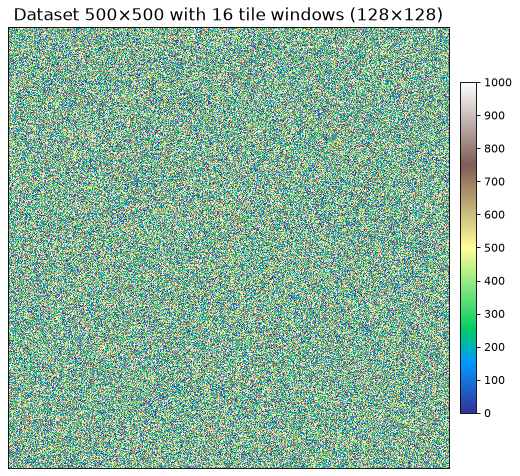

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(7, 6))
ds.plot(
    band=0,
    ax=ax,
    fig=fig,
    cmap="terrain",
    title=f"Dataset {ds.rows}×{ds.columns} with {len(windows)} tile windows (128×128)",
)
ax.set_xticks([])
ax.set_yticks([])
for win in windows:
    # Named fields, not positional unpacking: a Window is x-first.
    ax.add_patch(Rectangle((win.col_off - 0.5, win.row_off - 0.5), win.cols, win.rows,
                           linewidth=1.5, edgecolor="red", facecolor="none"))
fig.tight_layout()
plt.show()


## Per-tile computation example — global mean via streaming

Use the window iterator to compute the dataset-wide mean without ever reading more than one tile
at a time.

In [5]:
running_sum = 0.0
running_count = 0
for win in tile_windows(ds, tile_rows=128, tile_cols=128):
    # The window reads its own tile — no full-grid load, no manual slicing.
    tile = np.asarray(ds.read_array(window=win))
    valid = tile != -9999.0
    running_sum += float(tile[valid].sum())
    running_count += int(valid.sum())

streaming_mean = running_sum / running_count
direct_mean = float(z[z != -9999.0].mean())
print(f"Streaming mean:   {streaming_mean:.4f}")
print(f"Direct mean:      {direct_mean:.4f}")
np.testing.assert_allclose(streaming_mean, direct_mean, rtol=1e-5)

Streaming mean:   498.4214
Direct mean:      498.4214


## Overlapping windows — neighbour-context streaming

For algorithms that need neighbour context (slopes, flow direction, dilations) pass
`overlap=N` so adjacent tiles share an N-cell halo.

In [6]:
windows_overlap = list(tile_windows(ds, tile_rows=128, tile_cols=128, overlap=8))
print(f"Tiles with 8-cell overlap: {len(windows_overlap)}")
print(f"First 4 overlap windows:   {windows_overlap[:4]}")

Tiles with 8-cell overlap: 25
First 4 overlap windows:   [Window(col_off=0, row_off=0, cols=128, rows=128), Window(col_off=120, row_off=0, cols=128, rows=128), Window(col_off=240, row_off=0, cols=128, rows=128), Window(col_off=360, row_off=0, cols=128, rows=128)]


## `write_cog` — Cloud-Optimized GeoTIFF

Tiled GeoTIFF + internal overviews. Compatible with HTTP range reads / `s3://` reads from any
downstream cloud-aware GIS tool.

In [7]:
import tempfile, os
with tempfile.TemporaryDirectory() as tmp:
    cog_path = os.path.join(tmp, "continental.tif")
    written = write_cog(ds, cog_path, compress="deflate")
    size_mb = os.path.getsize(cog_path) / 1024 / 1024
    print(f"Wrote COG: {written}")
    print(f"File size: {size_mb:.2f} MB")

Wrote COG: C:\Users\main\AppData\Local\Temp\tmps9yav_25\continental.tif
File size: 0.82 MB


## Summary

* `tile_windows` is a generator — zero memory cost until you actually iterate. The streaming
  mean example demonstrates how a per-tile reduction can replace a full-grid load on continental
  rasters.
* `overlap=N` solves the neighbour-context problem for slopes / flow direction without changing
  the calling code.
* `write_cog` produces a Cloud-Optimized GeoTIFF in one call — tiled layout + DEFLATE compression
  + internal overviews for HTTP-range / `s3://` consumption.